## Dreamleague S21

In [15]:
%load_ext autoreload
%autoreload 2
from dotenv import load_dotenv
load_dotenv()
import pandas as pd
import os
from sqlalchemy.engine import create_engine, URL

from fetch_data import get_opendota_df
from preprocessing import preprocess_df
from team_features import create_team_level_features
from player_hero_features import create_player_hero_features
from heroes_features import create_hero_level_features
from opendota_match_details import fetch_match_details


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# league_id number for dreamleague season 21
league_id = 15739

# constants
label_col = 'radiant_win'
time_col = 'start_time'
uuid_col = 'match_id'


In [3]:
url_object = URL.create(
    "postgresql+psycopg2",
    username='liuhaochen',
    host='localhost',
    port='5432',
    database='test'
)

engine = create_engine(url_object)

In [4]:
df = pd.read_sql(
    "SELECT * FROM pro_matches",
    con=engine
)

df = preprocess_df(df)

In [5]:
df_dl = get_opendota_df(f'leagues/{league_id}/matches')
list_match_ids = df_dl['match_id']
list_match_ids

0     7350448037
1     7350256732
2     7350011127
3     7349896441
4     7349788555
         ...    
81    7342275176
82    7348581553
83    7343776797
84    7350558475
85    7343491898
Name: match_id, Length: 86, dtype: int64

In [6]:
dreamleague_dl = fetch_match_details(list_match_ids)


fetch_data - Request.. http://api.opendota.com/api/matches/7350448037
middlewares.track_api - API usage updated: {'20240831': 1, 'count': 17, 'last_reset_date': '20240901'}
fetch_data - API Response: Successfully fetched data for 7350448037
fetch_data - Request.. http://api.opendota.com/api/matches/7350256732
middlewares.track_api - API usage updated: {'20240831': 1, 'count': 18, 'last_reset_date': '20240901'}
fetch_data - API Response: Successfully fetched data for 7350256732
fetch_data - Request.. http://api.opendota.com/api/matches/7350011127
middlewares.track_api - API usage updated: {'20240831': 1, 'count': 19, 'last_reset_date': '20240901'}
fetch_data - API Response: Successfully fetched data for 7350011127
fetch_data - Request.. http://api.opendota.com/api/matches/7349896441
middlewares.track_api - API usage updated: {'20240831': 1, 'count': 20, 'last_reset_date': '20240901'}
fetch_data - API Response: Successfully fetched data for 7349896441
fetch_data - Request.. http://api.op

In [7]:
dreamleague_dl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   match_id         86 non-null     int64 
 1   radiant_team_id  86 non-null     int64 
 2   radiant_name     86 non-null     object
 3   dire_team_id     86 non-null     int64 
 4   dire_name        86 non-null     object
 5   duration         86 non-null     int64 
 6   start_time       86 non-null     int64 
 7   radiant_win      86 non-null     bool  
 8   0_account_id     86 non-null     int64 
 9   0_hero_id        86 non-null     int64 
 10  1_account_id     86 non-null     int64 
 11  1_hero_id        86 non-null     int64 
 12  2_account_id     86 non-null     int64 
 13  2_hero_id        86 non-null     int64 
 14  3_account_id     86 non-null     int64 
 15  3_hero_id        86 non-null     int64 
 16  4_account_id     86 non-null     int64 
 17  4_hero_id        86 non-null     int6

In [8]:
dreamleague_dl = preprocess_df(dreamleague_dl)
dreamleague_dl

,0_hero_id,1_hero_id,2_hero_id,3_hero_id,4_hero_id,128_hero_id,129_hero_id,130_hero_id,131_hero_id,132_hero_id,0_account_id,1_account_id,2_account_id,3_account_id,4_account_id,128_account_id,129_account_id,130_account_id,131_account_id,132_account_id,radiant_name,dire_name,radiant_win,start_time,match_id
0,73,17,60,58,90,41,79,107,101,135,86745912,154715080,126212866,94155156,25907144,321580662,113331514,106305042,256156323,302214028,Shopify Rebellion,Team Spirit,False,2023-09-25 01:09:00,7350558475
1,72,7,96,37,123,109,58,23,79,29,86745912,154715080,126212866,94155156,25907144,321580662,113331514,106305042,256156323,302214028,Shopify Rebellion,Team Spirit,False,2023-09-24 23:58:01,7350448037
2,12,68,107,110,96,46,74,38,58,79,321580662,113331514,106305042,256156323,302214028,86745912,154715080,126212866,94155156,25907144,Team Spirit,Shopify Rebellion,True,2023-09-24 22:18:00,7350256732
3,41,120,60,37,20,44,17,2,90,74,86745912,154715080,126212866,94155156,25907144,124801257,480412663,331855530,317880638,431770905,Shopify Rebellion,BetBoom Team,True,2023-09-24 20:18:06,7350011127
4,8,46,2,3,110,138,120,29,53,20,124801257,480412663,331855530,317880638,431770905,86745912,154715080,126212866,94155156,25907144,BetBoom Team,Shopify Rebellion,True,2023-09-24 19:09:03,7349896441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,14,46,135,3,100,89,120,75,16,138,86745912,154715080,126212866,94155156,25907144,171262902,96803083,127565532,183719386,196878136,Shopify Rebellion,Entity,False,2023-09-18 19:18:55,7340745014
82,37,93,101,38,114,7,137,20,18,90,10366616,100058342,94786276,86698277,94054712,100471531,301750126,101259972,375507918,193815691,Tundra Esports,Talon,True,2023-09-18 19:13:04,7340747836
83,37,7,55,69,73,20,135,107,119,44,134556694,858106446,165564598,161839895,132851371,54580962,73562326,201358612,77490514,152962063,9Pandas,Team Liquid,True,2023-09-18 18:13:34,7340677613
84,89,17,20,44,100,26,12,79,69,107,100471531,301750126,101259972,375507918,193815691,10366616,100058342,94786276,86698277,94054712,Talon,Tundra Esports,False,2023-09-18 17:58:40,7340671914


In [9]:
num_live_df = len(dreamleague_dl)
num_live_df 

86

In [10]:
cut_off_date = min(dreamleague_dl['start_time'])
cut_off_date

Timestamp('2023-09-18 17:57:33')

In [11]:
df_historical = df[df['start_time'] < cut_off_date]

In [12]:
combined_df = pd.concat([dreamleague_dl, df_historical])
combined_df

/var/folders/y7/llh2lh591fd8649s5dlf79_c0000gn/T/ipykernel_48138/2659608607.py:1: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  combined_df = pd.concat([dreamleague_dl, df_historical])


,0_hero_id,1_hero_id,2_hero_id,3_hero_id,4_hero_id,128_hero_id,129_hero_id,130_hero_id,131_hero_id,132_hero_id,0_account_id,1_account_id,2_account_id,3_account_id,4_account_id,128_account_id,129_account_id,130_account_id,131_account_id,132_account_id,radiant_name,dire_name,radiant_win,start_time,match_id
0,73.0,17.0,60.0,58.0,90.0,41.0,79.0,107.0,101.0,135.0,86745912.0,154715080.0,126212866.0,94155156.0,25907144.0,321580662.0,113331514.0,106305042.0,256156323.0,302214028.0,Shopify Rebellion,Team Spirit,False,2023-09-25 01:09:00,7.350558e+09
1,72.0,7.0,96.0,37.0,123.0,109.0,58.0,23.0,79.0,29.0,86745912.0,154715080.0,126212866.0,94155156.0,25907144.0,321580662.0,113331514.0,106305042.0,256156323.0,302214028.0,Shopify Rebellion,Team Spirit,False,2023-09-24 23:58:01,7.350448e+09
2,12.0,68.0,107.0,110.0,96.0,46.0,74.0,38.0,58.0,79.0,321580662.0,113331514.0,106305042.0,256156323.0,302214028.0,86745912.0,154715080.0,126212866.0,94155156.0,25907144.0,Team Spirit,Shopify Rebellion,True,2023-09-24 22:18:00,7.350257e+09
3,41.0,120.0,60.0,37.0,20.0,44.0,17.0,2.0,90.0,74.0,86745912.0,154715080.0,126212866.0,94155156.0,25907144.0,124801257.0,480412663.0,331855530.0,317880638.0,431770905.0,Shopify Rebellion,BetBoom Team,True,2023-09-24 20:18:06,7.350011e+09
4,8.0,46.0,2.0,3.0,110.0,138.0,120.0,29.0,53.0,20.0,124801257.0,480412663.0,331855530.0,317880638.0,431770905.0,86745912.0,154715080.0,126212866.0,94155156.0,25907144.0,BetBoom Team,Shopify Rebellion,True,2023-09-24 19:09:03,7.349896e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56480,58.0,98.0,19.0,42.0,111.0,41.0,68.0,96.0,128.0,46.0,126469785.0,118207269.0,230580807.0,318588173.0,76600360.0,874542740.0,67893845.0,93159453.0,79818006.0,172739956.0,Wind and Rain,felt,False,2021-05-18 08:02:06,5.999283e+09
56481,126.0,78.0,109.0,128.0,102.0,86.0,96.0,106.0,94.0,68.0,874542740.0,93159453.0,172739956.0,79818006.0,67893845.0,126469785.0,118207269.0,230580807.0,318588173.0,76600360.0,felt,Wind and Rain,False,2021-05-18 07:02:25,5.999250e+09
56482,96.0,123.0,15.0,121.0,72.0,23.0,2.0,94.0,128.0,30.0,118207269.0,126469785.0,230580807.0,76600360.0,318588173.0,874542740.0,93159453.0,172739956.0,79818006.0,67893845.0,Wind and Rain,felt,False,2021-05-18 06:02:01,5.999214e+09
56483,68.0,58.0,97.0,106.0,19.0,111.0,17.0,61.0,88.0,6.0,86818655.0,916319073.0,126174633.0,88611330.0,203851397.0,97366926.0,97072681.0,71266407.0,184131721.0,107579895.0,Infinity,Crewmates,True,2021-05-18 05:40:35,5.999202e+09


In [13]:
team_level_features = create_team_level_features(combined_df, num_live_df)
team_level_features

,radiant_dire_matchup,radiant_win_rate,dire_win_rate,radiant_win,start_time,match_id
0,0.800000,0.8,0.7,False,2023-09-25 01:09:00,7.350558e+09
1,0.800000,0.8,0.7,False,2023-09-24 23:58:01,7.350448e+09
2,0.700000,0.7,0.8,True,2023-09-24 22:18:00,7.350257e+09
3,0.888889,0.8,0.8,True,2023-09-24 20:18:06,7.350011e+09
4,0.750000,0.8,0.8,True,2023-09-24 19:09:03,7.349896e+09
...,...,...,...,...,...,...
81,0.700000,0.8,0.8,False,2023-09-18 19:18:55,7.340745e+09
82,0.900000,0.9,0.8,True,2023-09-18 19:13:04,7.340748e+09
83,0.750000,0.8,0.7,True,2023-09-18 18:13:34,7.340678e+09
84,0.700000,0.8,0.9,False,2023-09-18 17:58:40,7.340672e+09


In [17]:
heroes_features = create_hero_level_features(combined_df, num_live_df)
heroes_features

,match_id,Abaddon,Alchemist,Ancient Apparition,Anti-Mage,Arc Warden,Axe,Bane,Batrider,Beastmaster,Bloodseeker,Bounty Hunter,Brewmaster,Bristleback,Broodmother,Centaur Warrunner,Chaos Knight,Chen,Clinkz,Clockwerk,Crystal Maiden,Dark Seer,Dark Willow,Dawnbreaker,Dazzle,Death Prophet,Disruptor,Doom,Dragon Knight,Drow Ranger,Earth Spirit,Earthshaker,Elder Titan,Ember Spirit,Enchantress,Enigma,Faceless Void,Grimstroke,Gyrocopter,Hoodwink,...,Shadow Demon,Shadow Fiend,Shadow Shaman,Silencer,Skywrath Mage,Slardar,Slark,Snapfire,Sniper,Spectre,Spirit Breaker,Storm Spirit,Sven,Techies,Templar Assassin,Terrorblade,Tidehunter,Timbersaw,Tinker,Tiny,Treant Protector,Troll Warlord,Tusk,Underlord,Undying,Ursa,Vengeful Spirit,Venomancer,Viper,Visage,Void Spirit,Warlock,Weaver,Windranger,Winter Wyvern,Witch Doctor,Wraith King,Zeus,start_time,radiant_win
55611,7.350558e+09,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2023-09-25 01:09:00,False
55610,7.350448e+09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,1,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2023-09-24 23:58:01,False
55609,7.350257e+09,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2023-09-24 22:18:00,True
55608,7.350011e+09,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,2023-09-24 20:18:06,True
55607,7.349896e+09,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2023-09-24 19:09:03,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55530,7.340748e+09,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,2023-09-18 19:13:04,True
55529,7.340745e+09,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2023-09-18 19:18:55,False
55528,7.340678e+09,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,2023-09-18 18:13:34,True
55527,7.340676e+09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2023-09-18 17:57:33,False


In [18]:
player_hero_features = create_player_hero_features(combined_df, num_live_df)
player_hero_features

/Users/liuhaochen/Projects/projects/Dota2Predictor/backend/src/player_hero_features.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['win_rate'] = df_subset.apply(lambda row: last_10_matches_winrate(df_combined, row[TIME_COL], row['account_id'], row['hero_id']), axis=1)
/Users/liuhaochen/Projects/projects/Dota2Predictor/backend/src/player_hero_features.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['player_hero_win_rate_col'] = df_subset['player_num'].astype(str) + '_account_ '

player_hero_win_rate_col,match_id,0_account_ 0_hero_win_rate,128_account_ 128_hero_win_rate,129_account_ 129_hero_win_rate,130_account_ 130_hero_win_rate,131_account_ 131_hero_win_rate,132_account_ 132_hero_win_rate,1_account_ 1_hero_win_rate,2_account_ 2_hero_win_rate,3_account_ 3_hero_win_rate,4_account_ 4_hero_win_rate
85,7.350558e+09,0.800000,1.000000,0.900000,1.000000,0.9,0.666667,0.900,0.800000,0.900000,0.777778
84,7.350448e+09,1.000000,0.900000,0.900000,0.700000,1.0,0.700000,0.500,0.500000,0.833333,0.900000
83,7.350257e+09,0.900000,0.800000,0.800000,0.700000,0.9,0.750000,0.800,1.000000,0.700000,0.800000
82,7.350011e+09,0.555556,0.000000,0.800000,0.700000,0.9,0.800000,1.000,0.700000,0.800000,0.888889
81,7.349896e+09,0.600000,0.800000,1.000000,0.900000,0.5,0.875000,1.000,0.700000,1.000000,0.833333
...,...,...,...,...,...,...,...,...,...,...,...
4,7.340748e+09,1.000000,0.500000,0.000000,0.500000,1.0,0.625000,0.900,1.000000,0.800000,0.800000
3,7.340745e+09,1.000000,0.800000,0.600000,0.800000,0.8,0.500000,0.875,0.625000,0.800000,0.900000
2,7.340678e+09,0.500000,1.000000,0.714286,0.500000,1.0,0.000000,1.000,0.900000,1.000000,1.000000
1,7.340676e+09,0.700000,1.000000,0.857143,0.571429,0.8,0.800000,0.700,1.000000,0.700000,1.000000


In [19]:
df_final = pd.merge(pd.merge(team_level_features,heroes_features,how='inner', on=[time_col,label_col,uuid_col]), player_hero_features, how='inner', on=uuid_col)
df_final

,radiant_dire_matchup,radiant_win_rate,dire_win_rate,radiant_win,start_time,match_id,Abaddon,Alchemist,Ancient Apparition,Anti-Mage,Arc Warden,Axe,Bane,Batrider,Beastmaster,Bloodseeker,Bounty Hunter,Brewmaster,Bristleback,Broodmother,Centaur Warrunner,Chaos Knight,Chen,Clinkz,Clockwerk,Crystal Maiden,Dark Seer,Dark Willow,Dawnbreaker,Dazzle,Death Prophet,Disruptor,Doom,Dragon Knight,Drow Ranger,Earth Spirit,Earthshaker,Elder Titan,Ember Spirit,Enchantress,...,Sniper,Spectre,Spirit Breaker,Storm Spirit,Sven,Techies,Templar Assassin,Terrorblade,Tidehunter,Timbersaw,Tinker,Tiny,Treant Protector,Troll Warlord,Tusk,Underlord,Undying,Ursa,Vengeful Spirit,Venomancer,Viper,Visage,Void Spirit,Warlock,Weaver,Windranger,Winter Wyvern,Witch Doctor,Wraith King,Zeus,0_account_ 0_hero_win_rate,128_account_ 128_hero_win_rate,129_account_ 129_hero_win_rate,130_account_ 130_hero_win_rate,131_account_ 131_hero_win_rate,132_account_ 132_hero_win_rate,1_account_ 1_hero_win_rate,2_account_ 2_hero_win_rate,3_account_ 3_hero_win_rate,4_account_ 4_hero_win_rate
0,0.800000,0.8,0.7,False,2023-09-25 01:09:00,7.350558e+09,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.800000,1.000000,0.900000,1.000000,0.9,0.666667,0.900,0.800000,0.900000,0.777778
1,0.800000,0.8,0.7,False,2023-09-24 23:58:01,7.350448e+09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1.000000,0.900000,0.900000,0.700000,1.0,0.700000,0.500,0.500000,0.833333,0.900000
2,0.700000,0.7,0.8,True,2023-09-24 22:18:00,7.350257e+09,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.900000,0.800000,0.800000,0.700000,0.9,0.750000,0.800,1.000000,0.700000,0.800000
3,0.888889,0.8,0.8,True,2023-09-24 20:18:06,7.350011e+09,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0.555556,0.000000,0.800000,0.700000,0.9,0.800000,1.000,0.700000,0.800000,0.888889
4,0.750000,0.8,0.8,True,2023-09-24 19:09:03,7.349896e+09,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0.600000,0.800000,1.000000,0.900000,0.5,0.875000,1.000,0.700000,1.000000,0.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,0.700000,0.8,0.8,False,2023-09-18 19:18:55,7.340745e+09,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.000000,0.800000,0.600000,0.800000,0.8,0.500000,0.875,0.625000,0.800000,0.900000
82,0.900000,0.9,0.8,True,2023-09-18 19:13:04,7.340748e+09,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1.000000,0.500000,0.000000,0.500000,1.0,0.625000,0.900,1.000000,0.800000,0.800000
83,0.750000,0.8,0.7,True,2023-09-18 18:13:34,7.340678e+09,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0.500000,1.000000,0.714286,0.500000,1.0,0.000000,1.000,0.900000,1.000000,1.000000
84,0.700000,0.8,0.9,False,2023-09-18 17:58:40,7.340672e+09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0.800000,0.833333,0.500000,0.500000,0.5,0.800000,0.800,0.666667,0.800000,0.800000


In [21]:
from src.fetch_data import process_label, process_features

X = process_features(df_final)
y = process_label(df_final)

print(X.shape)
print(y.shape)

(86, 137)
(86,)


In [23]:
from joblib import load
from src.config import ROOT_DIR
clf = load(f'{ROOT_DIR}/models/random_forest_model.joblib')

In [27]:
y_pred = clf.predict(X)

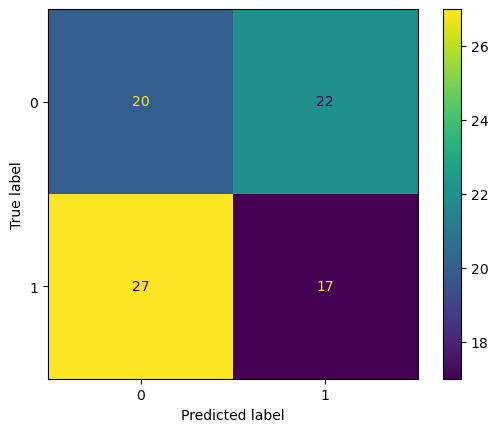

In [29]:
%matplotlib inline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()

In [30]:
from sklearn.metrics import accuracy_score

accuracy_score(y, y_pred) 

# Such high accuracy score might be an indication of ??

0.43023255813953487